# Preguntas de negocio

### 1. ¿Cuál es el impacto real de nuestra política de descuentos en el volumen de ventas?
* __Valor de negocio__: En MedTech, los ejecutivos de cuenta suelen dar descuentos para cerrar ventas, pero a veces esto solo erosiona el margen sin generar un aumento real en la adopción del producto. Necesitamos saber si "baratear" el equipo realmente funciona.
* __Concepto estadístico__: Correlación y Regresión Lineal Simple. No nos quedaremos con un simple gráfico de dispersión. Calcularemos el Coeficiente de Correlación de Pearson ($r$) entre Discount_Applied y Quantity. Además, plantearemos un modelo de regresión para estimar matemáticamente cuánto volumen extra genera cada punto porcentual de descuento, validando si el resultado es estadísticamente significativo a través de su $p-value$.

### 2. ¿Existen diferencias significativas en el ticket promedio de compra entre hospitales públicos y privados?
* __Valor de negocio__: Esto dicta hacia dónde dirigir el presupuesto de marketing y el esfuerzo de la fuerza de ventas. Si un sector gasta significativamente más, la estrategia de penetración debe ajustarse.
* __Concepto estadístico__: Prueba de Hipótesis (T-test para muestras independientes). Formularemos una hipótesis nula ($H_0$): "No hay diferencia en la media de ventas entre hospitales públicos y privados". Usaremos estadística inferencial para probar o rechazar esto con un nivel de confianza del 95% ($\alpha = 0.05$), demostrando que la diferencia no es producto del azar (ruido en los datos).

### 3. ¿Qué regiones o categorías de productos presentan anomalías severas en sus ventas (Outliers)?
* __Valor de negocio__: Un pico irreal de ventas puede ser un error de captura, fraude, o un éxito masivo temporal (ej. una licitación de gobierno). Identificarlos es vital para limpiar la proyección financiera.
* __Concepto estadístico__: Detección de valores atípicos (Outliers). Aplicaremos la regla del Rango Intercuartílico (IQR) y el cálculo de Z-scores ($Z = \frac{x - \mu}{\sigma}$). En el pipeline de limpieza, identificaremos matemáticamente qué transacciones se alejan más de 3 desviaciones estándar de la media para tratarlas antes de que ensucien el dashboard de Power BI.

### 4. ¿La satisfacción del cliente está ligada al volumen de equipos de imagenología adquiridos?
* __Valor de negocio__: Los equipos como tomógrafos o resonancias magnéticas requieren mantenimiento y servicio postventa. Queremos saber si una mala calificación de satisfacción nos está costando futuras compras de alto valor.
* __Concepto estadístico__: Análisis de Varianza (ANOVA) o Chi-Cuadrada. Primero aplicaremos técnicas de Imputación de Datos (como usar la media o mediana, o un modelo predictivo simple). Luego, dividiremos la satisfacción en categorías (Baja, Media, Alta) y aplicaremos ANOVA para ver si la varianza en las ventas de imagenología se explica por el nivel de satisfacción.

### 5. ¿Cuál es el comportamiento estacional y la tendencia de los productos consumibles frente a los quirúrgicos?
* __Valor de negocio__: Los consumibles (jeringas, gasas) deberían tener un flujo constante, mientras que los equipos quirúrgicos son compras esporádicas. Entender esta curva permite optimizar la cadena de suministro y evitar desabasto (stockouts) en el almacén.
* __Concepto estadístico__: Análisis de Series de Tiempo (Descomposición). Separaremos los datos en sus componentes fundamentales: tendencia (dirección a largo plazo), estacionalidad (patrones repetitivos) y ruido (variación aleatoria). Aplicaremos promedios móviles para suavizar las curvas de demanda y poder visualizar el verdadero comportamiento del mercado.

In [43]:
pip install pingouin

   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 1.4/1.4 MB 11.7 MB/s  0:00:00

   ---------- ----------------------------- 1/4 [xarray]
   ---------- ----------------------------- 1/4 [xarray]
   ---------- ----------------------------- 1/4 [xarray]
   ---------- ----------------------------- 1/4 [xarray]
   ---------- ----------------------------- 1/4 [xarray]
   ---------- ----------------------------- 1/4 [xarray]
   ---------- ----------------------------- 1/4 [xarray]
   ---------- ----------------------------- 1/4 [xarray]
   ---------- ----------------------------- 1/4 [xarray]
   ---------- ----------------------------- 1/4 [xarray]
   ---------- ----------------------------- 1/4 [xarray]
   ---------- ----------------------------- 1/4 [xarray]
   ---------- ----------------------------- 1/4 [xarray]
   ------------------------------ --------- 3/4 [pingouin]
   ---------------------------------------- 4/4 [pingoui

In [ ]:
# importación de librerías 
import pandas as pd
import numpy as np
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import pingouin as pg
import seaborn as sns
import matplotlib.pyplot as plt
import plotly

In [23]:
# Carga de datos 

df = pd.read_csv("../data/raw/medtech_sales_data.csv")
df.head()

,Order_ID,Date,Hospital_Type,Region,Product_Category,Product_Name,Quantity,Unit_Price_USD,Discount_Applied,Total_Sales_USD,Customer_Satisfaction
0,ORD-3032,2023-01-01,Privado,Sur,Consumibles,Jeringas 5ml,492,14.00,0.06,6474.72,8.7
1,ORD-5157,2023-01-01,Privado,Centro,Consumibles,Guantes de Nitrilo,512,16.72,0.02,8389.43,8.8
2,ORD-4246,2023-01-01,Público,Norte,Consumibles,Guantes de Nitrilo,528,15.88,0.02,8216.95,6.8
3,ORD-4047,2023-01-01,Público,Occidente,Quirúrgicos,Bisturí Ultrasónico,5,4582.19,0.04,21994.51,10.0
4,ORD-2137,2023-01-01,Público,Occidente,Consumibles,Catéteres,554,15.21,0.04,8089.29,NaN


In [46]:
df['Product_Category'].unique()

<StringArray>
['Consumibles', 'Quirúrgicos', 'Imagenología']
Length: 3, dtype: str

In [50]:
df[df['Product_Category'] == 'Consumibles'].describe()

,Quantity,Unit_Price_USD,Discount_Applied,Total_Sales_USD,Customer_Satisfaction
count,3488.000000,3488.000000,3488.000000,3488.000000,2797.000000
mean,611.154530,15.005272,0.030049,7274.243048,7.931319
std,2322.475974,2.005051,0.027391,1047.075635,1.391911
min,428.000000,7.780000,0.000000,4008.410000,2.600000
25%,484.000000,13.660000,0.010000,6552.457500,7.000000
50%,500.000000,14.970000,0.020000,7265.445000,8.000000
75%,515.000000,16.350000,0.040000,7991.462500,9.000000
max,50100.000000,23.300000,0.170000,11533.500000,10.000000


In [48]:
df[df['Product_Category'] == 'Quirúrgicos'].describe()

,Quantity,Unit_Price_USD,Discount_Applied,Total_Sales_USD,Customer_Satisfaction
count,1011.000000,1011.000000,1011.000000,1011.000000,803.000000
mean,5.506429,4990.636775,0.030653,24289.670554,7.941968
std,15.730109,499.619958,0.027618,11284.844317,1.416801
min,1.000000,3396.550000,0.000000,3617.960000,3.300000
25%,3.000000,4634.190000,0.010000,16368.725000,7.000000
50%,5.000000,4994.820000,0.020000,22924.980000,8.000000
75%,6.000000,5313.555000,0.040000,31306.630000,9.000000
max,500.000000,6725.280000,0.170000,68148.010000,10.000000


In [49]:
df[df['Product_Category'] == 'Imagenología'].describe()

,Quantity,Unit_Price_USD,Discount_Applied,Total_Sales_USD,Customer_Satisfaction
count,501.000000,501.000000,501.000000,5.010000e+02,400.000000
mean,2.520958,149038.590080,0.030180,2.797183e+05,7.895500
std,13.355675,20027.431934,0.028757,1.590763e+05,1.350422
min,1.000000,97332.680000,0.000000,8.954607e+04,3.500000
25%,1.000000,135961.920000,0.010000,1.491563e+05,7.000000
50%,2.000000,148883.570000,0.020000,2.634258e+05,8.000000
75%,2.000000,162732.850000,0.040000,3.484439e+05,8.900000
max,300.000000,217436.420000,0.180000,1.365797e+06,10.000000


In [24]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Order_ID               5000 non-null   str    
 1   Date                   5000 non-null   str    
 2   Hospital_Type          5000 non-null   str    
 3   Region                 4750 non-null   str    
 4   Product_Category       5000 non-null   str    
 5   Product_Name           5000 non-null   str    
 6   Quantity               5000 non-null   int64  
 7   Unit_Price_USD         5000 non-null   float64
 8   Discount_Applied       5000 non-null   float64
 9   Total_Sales_USD        5000 non-null   float64
 10  Customer_Satisfaction  4000 non-null   float64
dtypes: float64(4), int64(1), str(6)
memory usage: 429.8 KB


**Nota:** 

Region y Customer_Satisfatcion tienen datos faltantes

In [25]:
# Limpieza de outliers 
z_scores = np.abs(stats.zscore(df['Quantity']))
df_clean = df[z_scores < 3].copy()
print(f"Registros preservados después de limpiar outliers: {len(df_clean)}")

Registros preservados después de limpiar outliers: 4992


In [26]:
# Corrección de datos faltantas 

    # Región
df_clean['Region'] = df_clean['Region'].fillna("Desconocido")

    # Satisfacción de clientes
median_satisfaction = df_clean['Customer_Satisfaction'].median()
df_clean['Customer_Satisfaction'] = df_clean['Customer_Satisfaction'].fillna(median_satisfaction)

df_clean.info()

<class 'pandas.DataFrame'>
Index: 4992 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Order_ID               4992 non-null   str    
 1   Date                   4992 non-null   str    
 2   Hospital_Type          4992 non-null   str    
 3   Region                 4992 non-null   str    
 4   Product_Category       4992 non-null   str    
 5   Product_Name           4992 non-null   str    
 6   Quantity               4992 non-null   int64  
 7   Unit_Price_USD         4992 non-null   float64
 8   Discount_Applied       4992 non-null   float64
 9   Total_Sales_USD        4992 non-null   float64
 10  Customer_Satisfaction  4992 non-null   float64
dtypes: float64(4), int64(1), str(6)
memory usage: 468.0 KB


**Nota** 

Se eliminaron 8 registros después de la limpieza de outliers; no se tienen más datos null en el dataframe. 

In [27]:
# Correlación entre descuento y volumen de venta 
corr, p_value_corr = stats.pearsonr(df_clean['Discount_Applied'], df_clean['Quantity'])
print(f"Coeficiente de correlación(r): {corr:.2f}")
print(f"P valor : {p_value_corr:.2f}")

Coeficiente de correlación(r): -0.01
P valor : 0.66


**Nota** 

No se muestra una relación entre los descuentos aplicados y el volúmen de compra. Se debe revisar si existe diferencia en la correlación para diferentes segmentos de clientes. 

Tipo de cliente: Privado

- Coeficiente pearson: -0.01

- P-value: 0.84

 * Resultado no significativo

Tipo de cliente: Público

- Coeficiente pearson: 0.01

- P-value: 0.75

 * Resultado no significativo

Tipo de cliente: Clínica Especializada

- Coeficiente pearson: -0.04

- P-value: 0.20

 * Resultado no significativo



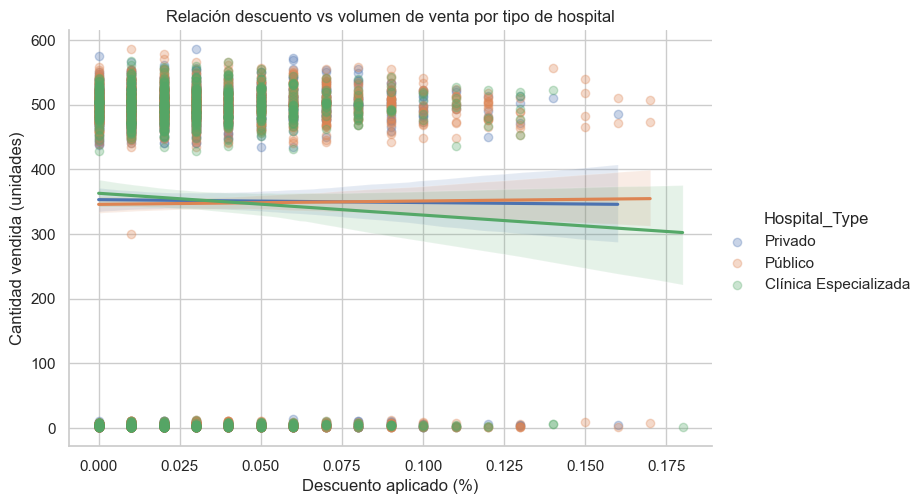

In [28]:
# Correlación para otros segmentos de mercado

for h_type in df_clean['Hospital_Type'].unique():
    subset = df_clean[df_clean['Hospital_Type'] == h_type]
    r, p_value_corr = stats.pearsonr(subset['Discount_Applied'], subset['Quantity'])
    print(f"Tipo de cliente: {h_type}")
    print(f"\n- Coeficiente pearson: {r:.2f}")
    print(f"\n- P-value: {p_value_corr:.2f}")

    if p_value_corr < 0.05:
        print("\n * Resultado estadístico significativa")
    else:
        print("\n * Resultado no significativo\n")



# Visualización de tendencia 
sns.set_theme(style = 'whitegrid')
g = sns.lmplot(
    data = df_clean, 
    x = 'Discount_Applied', 
    y= 'Quantity', 
    hue = 'Hospital_Type',
    height= 5, 
    aspect= 1.5, 
    scatter_kws={'alpha': 0.3}
)

g.set_axis_labels("Descuento aplicado (%)", "Cantidad vendida (unidades)")
plt.title("Relación descuento vs volumen de venta por tipo de hospital")
plt.show()


*Nota:*

No hay correlación entre el descuento aplicado y el volumen de venta para los segmentos de clientes. 

In [29]:
# Comparación del ticket promedio de hospítal público vs privado 

ventas_publico = df_clean[df_clean['Hospital_Type']== 'Público']['Total_Sales_USD']
ventas_privado = df_clean[df_clean['Hospital_Type']== 'Privado']['Total_Sales_USD']

t_stat, p_value_t = stats.ttest_ind(ventas_publico, ventas_privado, equal_var = False)

if p_value_t < 0.05:
    print(f"Existe una diferencia estadística significativa entre las medias de venta a hospital público: {ventas_publico.mean():.2f} y venta a hospital privado {ventas_privado.mean():.2f}")
    print(f"Estadístico T= {t_stat:.2f} | P-valor ={p_value_t:.2f}")
else:
    print(f"No existe una diferencia estadística significativa entre las medias de venta a hospital público: {ventas_publico.mean():.2f} y venta a hospital privado {ventas_privado.mean():.2f}")
    print(f"Estadístico T= {t_stat:.2f} | P-valor ={p_value_t:.2f}")

No existe una diferencia estadística significativa entre las medias de venta a hospital público: 37653.98 y venta a hospital privado 37776.44
Estadístico T= -0.04 | P-valor =0.97


In [30]:
# Compración del ticket promedio entre los diferente tipos de hosptiales en el dataset 

# Se usa ANOVA y post-hoc la prueba de Tukey y Games-Howell (asume heterocedasticidad)
grupos = [df_clean[df_clean['Hospital_Type'] == h]['Total_Sales_USD'] for h in df_clean['Hospital_Type'].unique()]

f_stat, p_value_anova = stats.f_oneway(*grupos)

print(f"Estadístico F: {f_stat:.2f}")
print(f"Valor P ANOVA: {p_value_anova:.2f}")

Estadístico F: 0.15
Valor P ANOVA: 0.86


In [ ]:
# Prueba de Tukey (se asume homocedasticidad)

tukey = pairwise_tukeyhsd(
    endog= df_clean['Total_Sales_USD'], 
    groups= df_clean['Hospital_Type'], 
    alpha = 0.05
)

print(tukey)

            Multiple Comparison of Means - Tukey HSD, FWER=0.05             
        group1         group2  meandiff  p-adj     lower      upper   reject
----------------------------------------------------------------------------
Clínica Especializada Privado -1745.4412 0.8958 -10901.5583 7410.6759  False
Clínica Especializada Público -1867.8984 0.8609 -10268.2365 6532.4397  False
              Privado Público  -122.4572 0.9992  -7435.2182 7190.3038  False
----------------------------------------------------------------------------


In [32]:
# Prueba de Games-Howell (se asume heterocedasticidad)
gh_test = pg.pairwise_gameshowell(
    data = df_clean, 
    dv = 'Total_Sales_USD', 
    between = 'Hospital_Type'
)

print(gh_test)

                       A        B        mean_A        mean_B         diff  \
0  Clínica Especializada  Privado  39521.882354  37776.441144  1745.441210   
1  Clínica Especializada  Público  39521.882354  37653.983960  1867.898394   
2                Privado  Público  37776.441144  37653.983960   122.457184   

            se         T           df      pval    hedges  
0  4099.487915  0.425771  2061.593619  0.904926  0.017555  
1  3716.992601  0.502529  1664.099849  0.870102  0.019741  
2  3114.647076  0.039317  3004.604214  0.999148  0.001304  


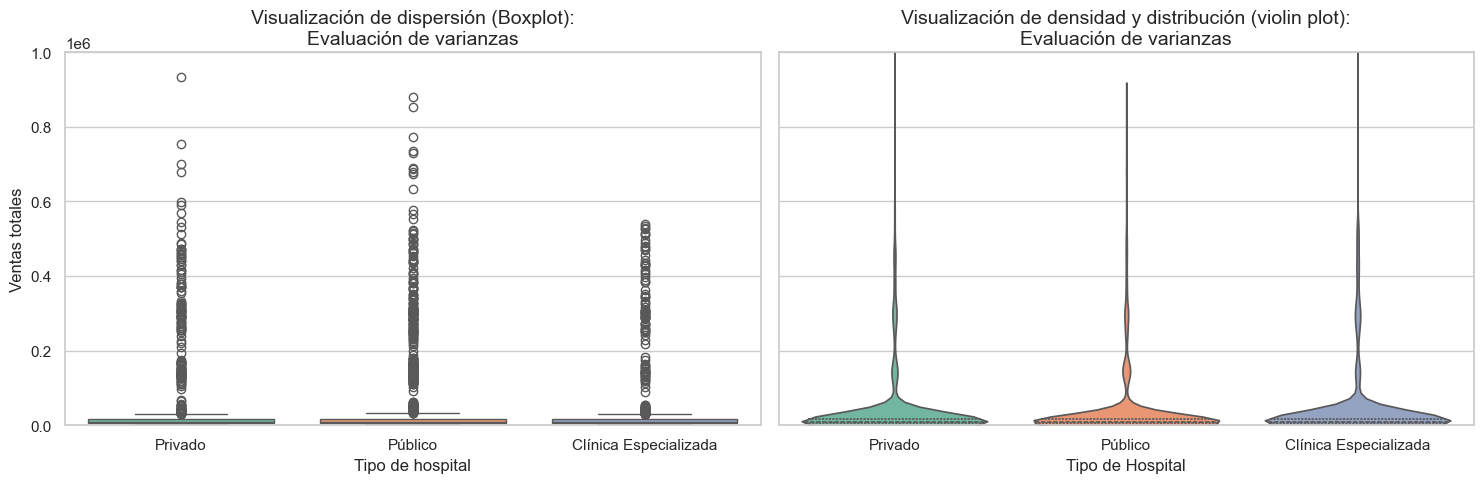

In [42]:
# Demostración gráfica de diferencia entre las varianzas 

sns.set_theme(style = 'whitegrid')

fig, (ax1, ax2) = plt.subplots(1,2,figsize = (15,5), sharey= True)

sns.boxplot(
    data = df_clean,
    x = 'Hospital_Type', 
    y = 'Total_Sales_USD', 
    hue = 'Hospital_Type',
    palette = 'Set2', 
    ax = ax1
)

ax1.set_title('Visualización de dispersión (Boxplot):\nEvaluación de varianzas', fontsize=14)
ax1.set_xlabel('Tipo de hospital', fontsize = 12)
ax1.set_ylabel('Ventas totales', fontsize = 12)
ax1.set_ylim(bottom= 0 , top = 1000000)

sns.violinplot(
    data = df_clean, 
    x = 'Hospital_Type',
    y = 'Total_Sales_USD', 
    palette = 'Set2',
    hue = 'Hospital_Type',
    inner = 'quartile'
)

ax2.set_title('Visualización de densidad y distribución (violin plot):\nEvaluación de varianzas', fontsize=14)
ax2.set_xlabel('Tipo de Hospital', fontsize=12)
ax2.set_ylabel('Ventas Totales (USD)', fontsize=12)

plt.tight_layout()
plt.show()


Text(0.5, 0, 'Tipo de Hospital')

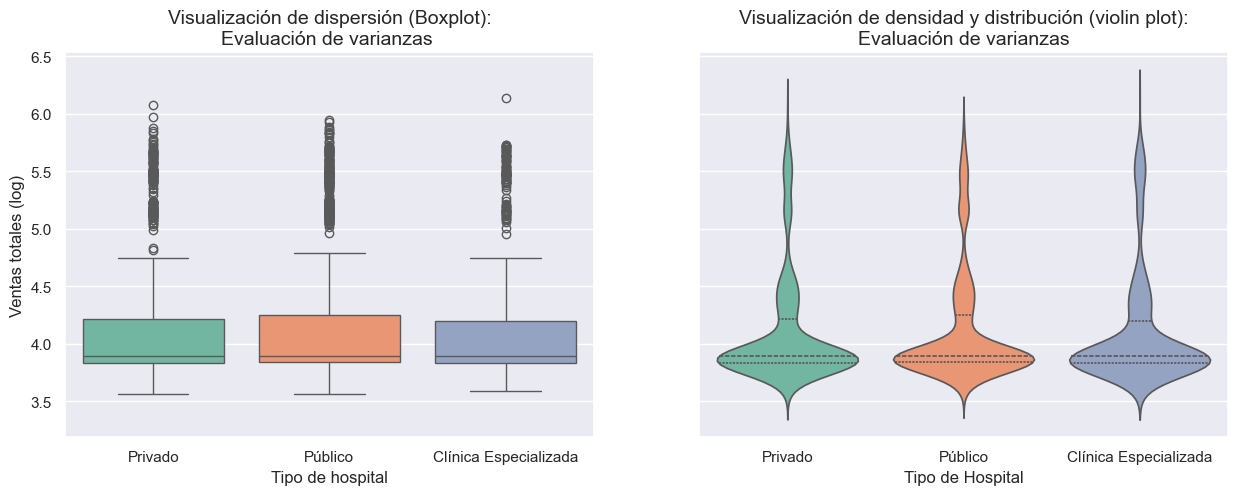

In [45]:
# Aplicación de escala logaritmica en el eje y para ver mejor la distribución 
df_log = df_clean.copy()

df_log['Sales_log'] = np.log10(df_log['Total_Sales_USD'])

sns.set_theme(style = 'darkgrid')

fig, (ax1, ax2) = plt.subplots(1,2,figsize = (15,5), sharey= True)

sns.boxplot(
    data = df_log,
    x = 'Hospital_Type', 
    y = 'Sales_log', 
    hue = 'Hospital_Type',
    palette = 'Set2', 
    ax = ax1
)

ax1.set_title('Visualización de dispersión (Boxplot):\nEvaluación de varianzas ', fontsize=14)
ax1.set_xlabel('Tipo de hospital', fontsize = 12)
ax1.set_ylabel('Ventas totales (log)', fontsize = 12)

sns.violinplot(
    data = df_log, 
    x = 'Hospital_Type',
    y = 'Sales_log', 
    palette = 'Set2',
    hue = 'Hospital_Type',
    inner = 'quartile'
)

ax2.set_title('Visualización de densidad y distribución (violin plot):\nEvaluación de varianzas', fontsize=14)
ax2.set_xlabel('Tipo de Hospital', fontsize=12)

In [59]:
# Definición de lógica de segmentación de ventas para los dos tipos de productos 'Consumible alto volumen' | 'Equipos_medicos'

def segmentador(categoria):
  if categoria == 'Consumibles':
       return 'Consumible alto volumen'
  else:
       return 'Equipo medico alto valor'

df_clean['Business_unit'] = df_clean['Product_Category'].map(segmentador)

df_clean.sample(10)

,Order_ID,Date,Hospital_Type,Region,Product_Category,Product_Name,Quantity,Unit_Price_USD,Discount_Applied,Total_Sales_USD,Customer_Satisfaction,Business_unit
1454,ORD-5463,2023-08-02,Público,Centro,Quirúrgicos,Mesa Quirúrgica,10,5981.86,0.02,58622.23,10.0,Equipo medico alto valor
4228,ORD-5504,2024-09-13,Público,Occidente,Quirúrgicos,Lámpara Cialítica,9,4725.87,0.01,42107.50,7.7,Equipo medico alto valor
3250,ORD-5580,2024-04-25,Público,Occidente,Consumibles,Gasas Estériles,485,17.24,0.00,8361.40,7.1,Consumible alto volumen
4044,ORD-1919,2024-08-17,Clínica Especializada,Centro,Consumibles,Guantes de Nitrilo,500,13.02,0.05,6184.50,6.7,Consumible alto volumen
998,ORD-2497,2023-05-26,Público,Centro,Consumibles,Gasas Estériles,473,14.77,0.00,6986.21,6.5,Consumible alto volumen
952,ORD-4931,2023-05-19,Privado,Centro,Consumibles,Catéteres,511,19.23,0.03,9531.73,6.7,Consumible alto volumen
1641,ORD-2483,2023-08-27,Privado,Occidente,Consumibles,Catéteres,507,18.15,0.01,9110.03,8.0,Consumible alto volumen
4285,ORD-2181,2024-09-21,Público,Centro,Quirúrgicos,Lámpara Cialítica,9,5280.86,0.01,47052.46,8.1,Equipo medico alto valor
1290,ORD-4218,2023-07-09,Privado,Sur,Consumibles,Jeringas 5ml,517,15.93,0.03,7988.74,7.6,Consumible alto volumen
2034,ORD-4257,2023-10-28,Privado,Bajío,Consumibles,Guantes de Nitrilo,523,13.90,0.03,7051.61,8.6,Consumible alto volumen


In [ ]:
# Alternativo con diccionario 

"""seg__map = {
    'Consumibles' : 'Consumible alto volumne', 
    'Quirúrgicos' : 'Equipo medico alto valor', 
    'Imagenología': 'Imagenología'
}


df_clean['Business_unit'] = df_clean['Product_Category'].map(seg__map)"""


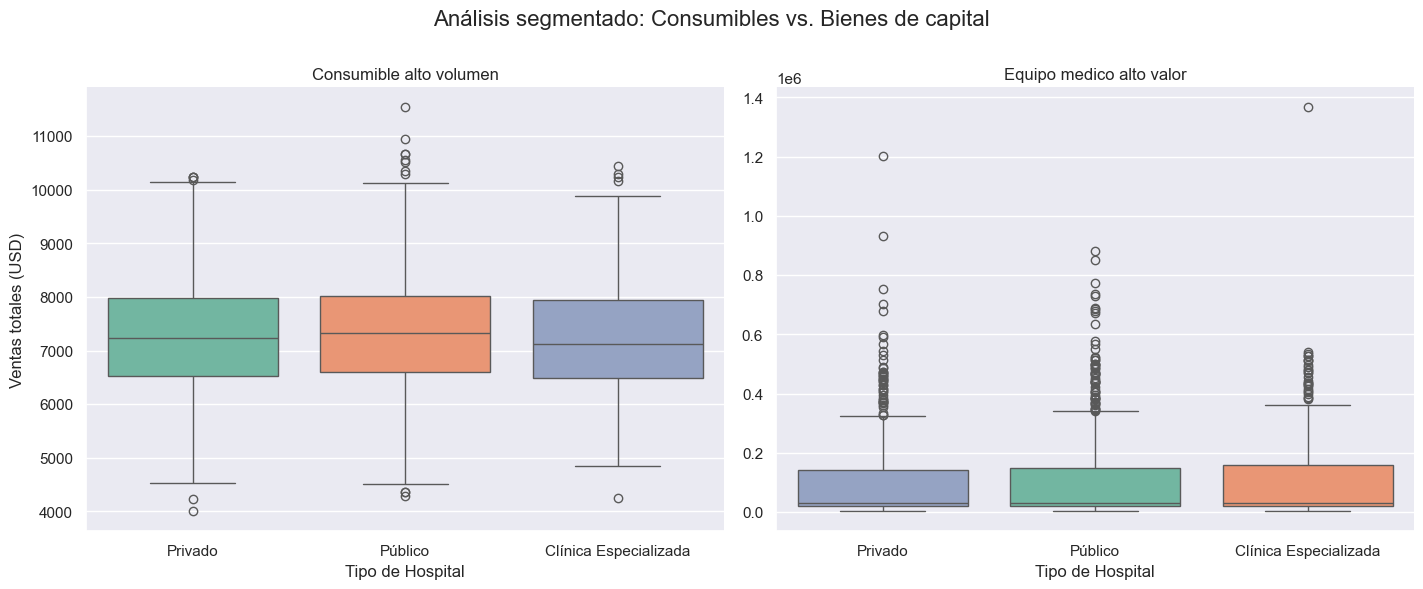

In [ ]:
# Gráica con FacetGrid boxplot 

g = sns.FacetGrid(df_clean, col="Business_unit", sharey=False, sharex=False, height=6, aspect=1.2)
g.map_dataframe(
    sns.boxplot, 
    x='Hospital_Type', 
    y='Total_Sales_USD', 
    hue = 'Hospital_Type',
    palette='Set2',
    order = ['Privado', 'Público', 'Clínica Especializada']
    )

# Ajustes estéticos
g.set_axis_labels("Tipo de Hospital", "Ventas totales (USD)")
g.set_titles("{col_name}")
plt.subplots_adjust(top=0.85)
g.fig.suptitle('Análisis segmentado: Consumibles vs. Bienes de capital', fontsize=16)
plt.show()

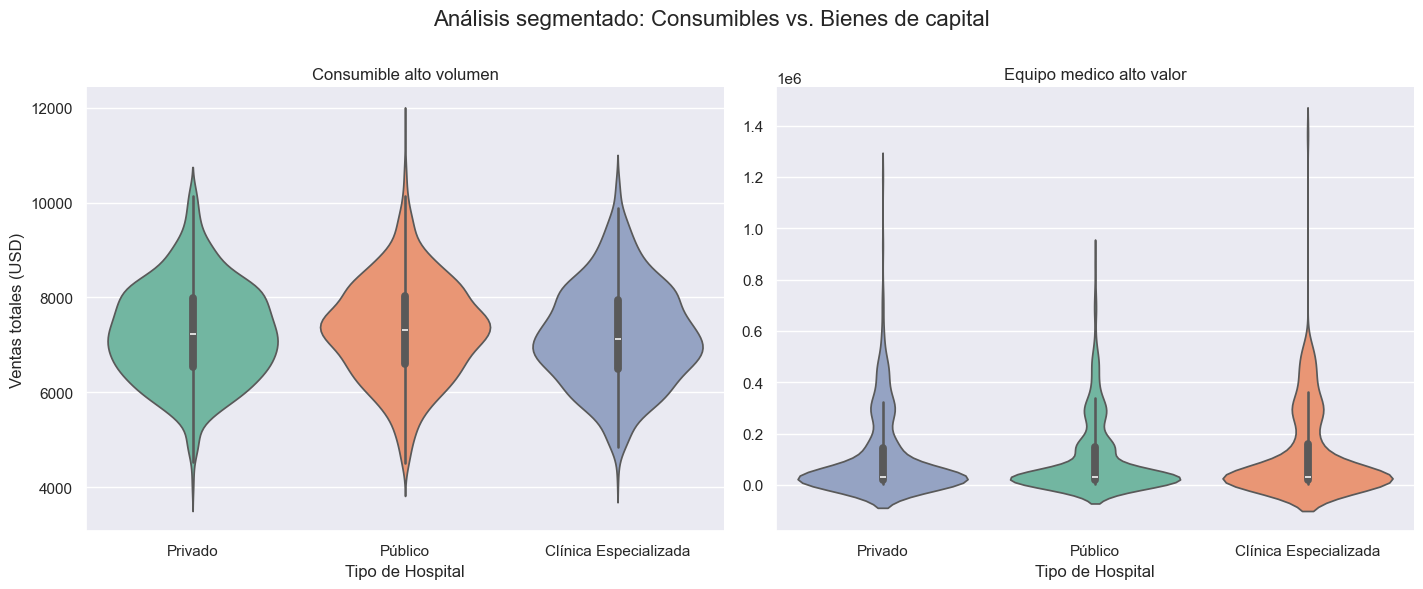

In [64]:


g = sns.FacetGrid(df_clean, col="Business_unit", sharey=False, sharex=False, height=6, aspect=1.2)
g.map_dataframe(
    sns.violinplot, 
    x='Hospital_Type', 
    y='Total_Sales_USD', 
    hue = 'Hospital_Type',
    palette='Set2',
    order = ['Privado', 'Público', 'Clínica Especializada']
    )

# Ajustes estéticos
g.set_axis_labels("Tipo de Hospital", "Ventas totales (USD)")
g.set_titles("{col_name}")
plt.subplots_adjust(top=0.85)
g.fig.suptitle('Análisis segmentado: Consumibles vs. Bienes de capital', fontsize=16)
plt.show()

*Nota:*

Cuando se segmentan las ventas por Business_unit se observa que la varianza es homogénea. Pero ya se había mencaiondo que no hay diferencia estadística significativa entre los tickets medios entre los diferentes tipos de hospital. 

In [67]:
# Detección de regiones con ventas muy altas, sujetas a investigación para ver si son legitimas, licitaciones ganadas, o fraudes

def detect_zcore_outliers(data, column, threshold = 3):

    z_scores = np.abs(stats.zscore(data[column]))

    return data[z_scores < threshold]



def detect_iqr_outliers(data, group_col, target_col):

    outliers_list = []

    for group in data[group_col].unique():
        subset = data[data[group_col] == group]
        q1 = subset[target_col].quantile(0.25)
        q3 = subset[target_col].quantile(0.75)
        IQR = q3 - q1 

        lower_bound = q1 - 1.5 * IQR
        upper_bound = q3 + 1.5 * IQR 

        anomalias = subset[(subset[target_col] < lower_bound)|(subset[target_col] > upper_bound)]
        outliers_list.append(anomalias)

    return pd.concat(outliers_list)



    

In [77]:
outliers_z = detect_zcore_outliers(df, 'Total_Sales_USD')
print(f"Anomalías detectas por z_score (Global) = {len(outliers_z)}")

Anomalías detectas por z_score (Global) = 4855


In [80]:
reporte_anomalias = outliers_z.groupby(['Region', 'Product_Category']).size().reset_index(name='Num_Anomalias')
reporte_anomalias = reporte_anomalias.sort_values(by='Num_Anomalias', ascending=False)

print("\n Top de regiones/categorías con mayor índice de anomalías")
print(reporte_anomalias)


 Top de regiones/categorías con mayor índice de anomalías
       Region Product_Category  Num_Anomalias
0       Bajío      Consumibles            718
3      Centro      Consumibles            669
9   Occidente      Consumibles            657
6       Norte      Consumibles            652
12        Sur      Consumibles            616
11  Occidente      Quirúrgicos            213
5      Centro      Quirúrgicos            207
2       Bajío      Quirúrgicos            181
8       Norte      Quirúrgicos            181
14        Sur      Quirúrgicos            179
7       Norte     Imagenología             75
13        Sur     Imagenología             73
10  Occidente     Imagenología             68
4      Centro     Imagenología             64
1       Bajío     Imagenología             57


In [78]:
outliers_iqr = detect_iqr_outliers(df, 'Product_Category', 'Total_Sales_USD')
print(f"Anomalías detectadas por IQR (Segmentado) : {len(outliers_iqr)}")

Anomalías detectadas por IQR (Segmentado) : 53


In [79]:

reporte_anomalias = outliers_iqr.groupby(['Region', 'Product_Category']).size().reset_index(name='Num_Anomalias')
reporte_anomalias = reporte_anomalias.sort_values(by='Num_Anomalias', ascending=False)

print("\n Top de regiones/categorías con mayor índice de anomalías")
print(reporte_anomalias)


 Top de regiones/categorías con mayor índice de anomalías
       Region Product_Category  Num_Anomalias
5       Norte      Consumibles             11
8   Occidente      Consumibles              6
10  Occidente      Quirúrgicos              5
7       Norte      Quirúrgicos              4
0       Bajío     Imagenología              4
4      Centro      Quirúrgicos              3
3      Centro     Imagenología              3
2      Centro      Consumibles              3
1       Bajío      Quirúrgicos              3
11        Sur     Imagenología              3
9   Occidente     Imagenología              3
6       Norte     Imagenología              1
12        Sur      Quirúrgicos              1


Inicialmente se evaluó la detección de anomalías mediante Z-Score global, resultando en un falso positivo del 97% del dataset. Esto confirmó matemáticamente la naturaleza multimodal de los datos de MedTech, donde la media global no es representativa.

Se pivotó hacia un enfoque de IQR Segmentado por Categoría, logrando identificar con precisión 53 anomalías críticas (errores de captura y outliers de negocio), permitiendo una limpieza efectiva sin comprometer la integridad de los datos de volumen